In [ ]:
import pandas as pd
import numpy as np
from scipy.fft import fft

catmap = pd.read_csv("data/catmap.csv")
consDF = pd.read_parquet("data/Consumer.pqt").drop(columns=["credit_score"])
consDF = consDF.dropna(subset=['DQ_TARGET'])

acctDF = pd.read_parquet("data/Account.pqt")
trxnDF = pd.read_parquet("data/Transaction.pqt").drop_duplicates()

acctDF['balance_date'] = pd.to_datetime(acctDF['balance_date'])
trxnDF['posted_date'] = pd.to_datetime(trxnDF['posted_date'])

date_stats = acctDF.groupby('prism_consumer_id')['balance_date'].agg(['min', 'max'])
valid_ids = date_stats[(date_stats['max'] - date_stats['min']).dt.days <= 2].index

consDF = consDF[consDF['prism_consumer_id'].isin(valid_ids)]
acctDF = acctDF[acctDF['prism_consumer_id'].isin(valid_ids)]
trxnDF = trxnDF[trxnDF['prism_consumer_id'].isin(valid_ids)]

trxnDF['signed_amount'] = np.where(
    trxnDF['credit_or_debit'] == 'DEBIT', 
    -trxnDF['amount'], 
    trxnDF['amount']
)
trxnDF = trxnDF.sort_values(['prism_consumer_id', 'posted_date', 'prism_transaction_id'])
trxnDF['raw_cumsum'] = trxnDF.groupby('prism_consumer_id')['signed_amount'].cumsum()

snapshot = acctDF.sort_values('balance_date').groupby('prism_consumer_id').tail(1)
snapshot = snapshot.rename(columns={'balance': 'snapshot_balance', 'balance_date': 'snapshot_date'})

df_merged = trxnDF.merge(snapshot[['prism_consumer_id', 'snapshot_date', 'snapshot_balance']], on='prism_consumer_id', how='left')

anchor = df_merged[df_merged['posted_date'] <= df_merged['snapshot_date']].groupby('prism_consumer_id')['raw_cumsum'].last().rename('cumsum_at_snapshot')
df_merged = df_merged.merge(anchor, on='prism_consumer_id', how='left')

df_merged['running_balance'] = (df_merged['raw_cumsum'] - df_merged['cumsum_at_snapshot']) + df_merged['snapshot_balance']

history_df = df_merged[[
    'prism_consumer_id', 
    'posted_date', 
    'category', 
    'amount', 
    'signed_amount',
    'credit_or_debit', 
    'running_balance'
]].merge(consDF[['prism_consumer_id', 'DQ_TARGET']], on='prism_consumer_id', how='inner')

spend_df = history_df[history_df['credit_or_debit'] == 'DEBIT']
raw_stats = spend_df.groupby('prism_consumer_id')['amount'].agg(['mean', 'min', 'max']).add_prefix('trans_global_spend_')

monthly_baskets = spend_df.groupby([
    'prism_consumer_id', 
    pd.Grouper(key='posted_date', freq='ME'), 
    'category'
])['amount'].sum().unstack(level='category', fill_value=0)

monthly_totals = monthly_baskets.sum(axis=1).to_frame('total_spend')

rolling_dfs = []
for m in [1, 3, 6, 12]:
    cat_roll = monthly_baskets.groupby('prism_consumer_id').rolling(window=m, min_periods=1).agg(['mean', 'max'])
    cat_roll.columns = [f'{col[0]}_{m}m_spend_{col[1]}' for col in cat_roll.columns]
    
    tot_roll = monthly_totals.groupby('prism_consumer_id').rolling(window=m, min_periods=1).agg(['mean', 'min', 'max'])
    tot_roll.columns = [f'{col[0]}_{m}m_{col[1]}' for col in tot_roll.columns]
    
    combined = pd.concat([cat_roll, tot_roll], axis=1)
    rolling_dfs.append(combined.groupby('prism_consumer_id').tail(1).reset_index(level=1, drop=True))

final_rolling = pd.concat(rolling_dfs, axis=1)

income_cols = [3, 7, 45, 49]
income_mask = history_df['category'].isin(income_cols)

monthly_income = history_df[income_mask].groupby([
    'prism_consumer_id', 
    pd.Grouper(key='posted_date', freq='ME')
])['signed_amount'].sum()

def calc_fft_features(series):
    if isinstance(series.index, pd.MultiIndex):
        series = series.droplevel(0)
    series = series.asfreq('ME', fill_value=0)
    n = len(series)
    if n < 2:
        return pd.Series([series.mean(), 0.0], index=['income_fft_dc', 'income_fft_stability'])
    y = fft(series.values)
    dc = np.abs(y[0]) / n
    stability = np.abs(y[1]) / n
    return pd.Series([dc, stability], index=['income_fft_dc', 'income_fft_stability'])

fft_features = monthly_income.groupby('prism_consumer_id').apply(calc_fft_features).unstack()

targets = history_df[['prism_consumer_id', 'DQ_TARGET']].drop_duplicates().set_index('prism_consumer_id')
final_rolling['income_data_missing'] = fft_features['income_fft_dc'].isna().astype(int)

final_product = (final_rolling
                 .join(raw_stats, how='left')
                 .join(fft_features, how='left')
                 .join(targets, how='inner')
                 .fillna(0))

final_product

,,0_1m_spend_mean,0_1m_spend_max,1_1m_spend_mean,1_1m_spend_max,4_1m_spend_mean,4_1m_spend_max,11_1m_spend_mean,11_1m_spend_max,12_1m_spend_mean,12_1m_spend_max,...,total_spend_12m_mean,total_spend_12m_min,total_spend_12m_max,income_data_missing,trans_global_spend_mean,trans_global_spend_min,trans_global_spend_max,income_fft_dc,income_fft_stability,DQ_TARGET
prism_consumer_id,posted_date,,,,,,,,,,,,,,,,,,,,,
0,2021-09-30,20.00,20.00,330.00,330.00,0.00,0.00,0.0,0.0,0.00,0.00,...,2129.772857,765.50,3652.37,0.0,40.293000,0.00,500.00,1260.080000,90.052936,0.0
1,2021-07-31,1700.00,1700.00,2.42,2.42,15.37,15.37,0.0,0.0,0.00,0.00,...,3299.767143,1918.38,5980.25,0.0,95.055021,0.92,1390.85,1702.662857,159.813237,0.0
10,2022-02-28,500.00,500.00,964.00,964.00,0.00,0.00,0.0,0.0,0.00,0.00,...,3109.514286,1119.21,3893.68,0.0,85.025781,0.00,625.00,2102.962857,429.022154,0.0
1000,2023-02-28,5942.87,5942.87,922.15,922.15,0.00,0.00,0.0,0.0,201.97,201.97,...,11130.712857,1318.08,27497.57,0.0,533.664315,5.00,10000.00,8862.161667,1890.441553,0.0
10000,2022-03-31,0.00,0.00,423.00,423.00,30.83,30.83,0.0,0.0,0.00,0.00,...,10963.414286,2270.69,53243.82,0.0,164.686481,0.82,13377.97,2227.018750,504.215943,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
994,2022-02-28,200.00,200.00,47.90,47.90,0.00,0.00,0.0,0.0,0.00,0.00,...,2484.405714,1065.84,3613.39,0.0,48.442451,0.99,1000.00,1893.062857,326.989150,0.0
995,2021-11-30,0.00,0.00,0.00,0.00,0.00,0.00,0.0,0.0,35.00,35.00,...,4495.210000,1433.37,8887.79,0.0,342.026848,0.33,2000.00,4797.042857,1013.271358,0.0
997,2022-04-30,5559.99,5559.99,1662.28,1662.28,193.16,193.16,0.0,0.0,0.00,0.00,...,11582.371429,5864.28,15689.82,0.0,232.978736,0.30,4048.99,4595.130000,1097.141354,0.0


In [62]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import StandardScaler

X = final_product.drop(columns=['DQ_TARGET'])
y = final_product['DQ_TARGET']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3 , stratify=y
)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = LogisticRegression(max_iter=1000, class_weight='balanced')
model.fit(X_train_scaled, y_train)

train_probs = model.predict_proba(X_train_scaled)[:, 1]
test_probs = model.predict_proba(X_test_scaled)[:, 1]

print(f"Train ROC AUC: {roc_auc_score(y_train, train_probs):.4f}")
print(f"Test ROC AUC:  {roc_auc_score(y_test, test_probs):.4f}")

Train ROC AUC: 0.8031
Test ROC AUC:  0.6936


In [63]:
import xgboost as xgb

X = final_product.drop(columns=['DQ_TARGET', 'posted_date', 'prism_consumer_id'], errors='ignore')
y = final_product['DQ_TARGET']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y
)


ratio = float(np.sum(y_train == 0)) / np.sum(y_train == 1)

model = xgb.XGBClassifier(
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.5,
    scale_pos_weight=ratio,
    random_state=42,
    n_jobs=-1
)

model.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_test, y_test)],
    verbose=100
)

train_probs = model.predict_proba(X_train)[:, 1]
test_probs = model.predict_proba(X_test)[:, 1]

print(f"\nTrain ROC AUC: {roc_auc_score(y_train, train_probs):.4f}")
print(f"Test ROC AUC:  {roc_auc_score(y_test, test_probs):.4f}")

[0]	validation_0-logloss:0.68064	validation_1-logloss:0.68243
[100]	validation_0-logloss:0.36057	validation_1-logloss:0.43972
[200]	validation_0-logloss:0.26011	validation_1-logloss:0.37674
[300]	validation_0-logloss:0.18871	validation_1-logloss:0.33638
[400]	validation_0-logloss:0.13722	validation_1-logloss:0.30952
[500]	validation_0-logloss:0.10145	validation_1-logloss:0.29551
[600]	validation_0-logloss:0.07631	validation_1-logloss:0.28916
[700]	validation_0-logloss:0.05763	validation_1-logloss:0.28917
[800]	validation_0-logloss:0.04535	validation_1-logloss:0.29150
[900]	validation_0-logloss:0.03616	validation_1-logloss:0.29475
[999]	validation_0-logloss:0.02919	validation_1-logloss:0.29858

Train ROC AUC: 1.0000
Test ROC AUC:  0.7327


In [64]:
sparsity = (final_product == 0).mean()
drop_sparse = sparsity[sparsity > 0.97].index
print(f"Dropping {len(drop_sparse)} columns that are mostly zeros (e.g., rare categories).")

cols_to_drop = list(set(drop_sparse))

safe_cols = ['prism_consumer_id', 'posted_date', 'DQ_TARGET', 'income_data_missing']
cols_to_drop = [c for c in cols_to_drop if c not in safe_cols]

final_lean = final_product.drop(columns=cols_to_drop)

print(f"\nOriginal Shape: {final_product.shape}")
print(f"New Lean Shape: {final_lean.shape}")

Dropping 27 columns that are mostly zeros (e.g., rare categories).

Original Shape: (9678, 331)
New Lean Shape: (9678, 305)


In [65]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import StandardScaler

X = final_lean.drop(columns=['DQ_TARGET'])
y = final_lean['DQ_TARGET']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3 , stratify=y
)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = LogisticRegression(max_iter=1000, class_weight='balanced')
model.fit(X_train_scaled, y_train)

train_probs = model.predict_proba(X_train_scaled)[:, 1]
test_probs = model.predict_proba(X_test_scaled)[:, 1]

print(f"Train ROC AUC: {roc_auc_score(y_train, train_probs):.4f}")
print(f"Test ROC AUC:  {roc_auc_score(y_test, test_probs):.4f}")

Train ROC AUC: 0.8023
Test ROC AUC:  0.6825


In [66]:
import xgboost as xgb

X = final_lean.drop(columns=['DQ_TARGET', 'posted_date', 'prism_consumer_id'], errors='ignore')
y = final_lean['DQ_TARGET']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y
)


ratio = float(np.sum(y_train == 0)) / np.sum(y_train == 1)

model = xgb.XGBClassifier(
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.5,
    scale_pos_weight=ratio,
    random_state=42,
    n_jobs=-1
)

model.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_test, y_test)],
    verbose=100
)

train_probs = model.predict_proba(X_train)[:, 1]
test_probs = model.predict_proba(X_test)[:, 1]

print(f"\nTrain ROC AUC: {roc_auc_score(y_train, train_probs):.4f}")
print(f"Test ROC AUC:  {roc_auc_score(y_test, test_probs):.4f}")

[0]	validation_0-logloss:0.68144	validation_1-logloss:0.68210
[100]	validation_0-logloss:0.36627	validation_1-logloss:0.43458
[200]	validation_0-logloss:0.26035	validation_1-logloss:0.36659
[300]	validation_0-logloss:0.18422	validation_1-logloss:0.32450
[400]	validation_0-logloss:0.13418	validation_1-logloss:0.29925
[500]	validation_0-logloss:0.09765	validation_1-logloss:0.28539
[600]	validation_0-logloss:0.07131	validation_1-logloss:0.27733
[700]	validation_0-logloss:0.05269	validation_1-logloss:0.27673
[800]	validation_0-logloss:0.04058	validation_1-logloss:0.27944
[900]	validation_0-logloss:0.03162	validation_1-logloss:0.28415
[999]	validation_0-logloss:0.02492	validation_1-logloss:0.28852

Train ROC AUC: 1.0000
Test ROC AUC:  0.7558


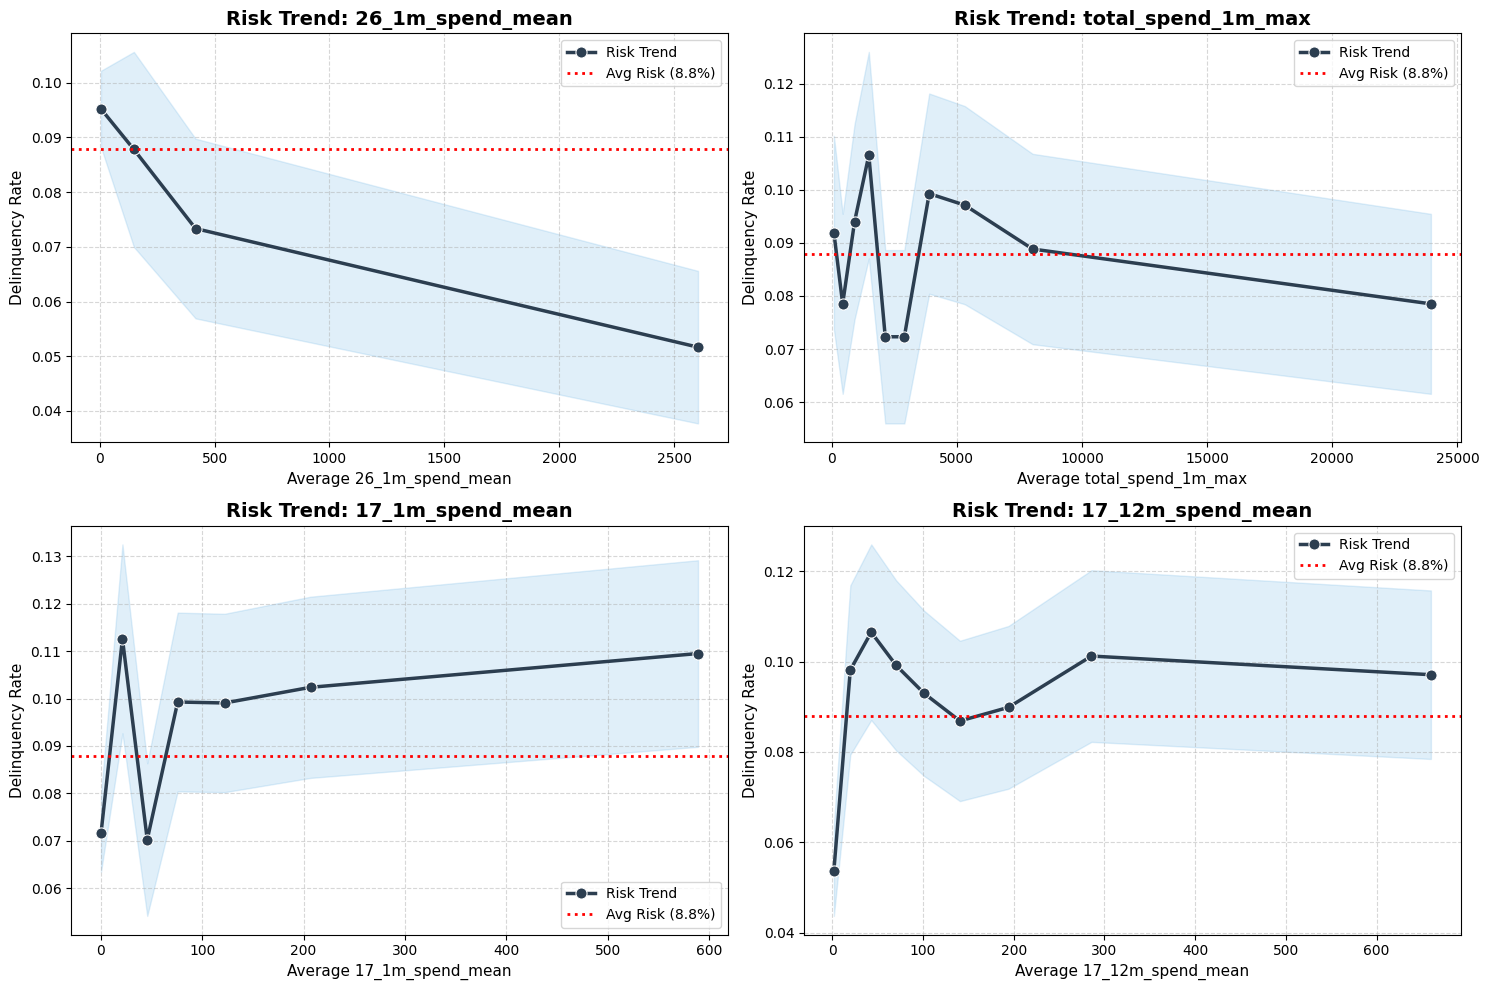

In [76]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

def plot_feature_risk_trends(df, features, target='DQ_TARGET', bins=10):
    """
    Plots the trend of Delinquency Risk against specific features using decile binning.
    Includes error bands and a global average baseline.
    """
    # Calculate grid size dynamically
    n_features = len(features)
    n_cols = 2
    n_rows = (n_features + 1) // n_cols
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5 * n_rows))
    axes = axes.flatten() if n_features > 1 else [axes]
    
    # Styling
    line_color = '#2c3e50'  # Dark Blue-Grey
    fill_color = '#3498db'  # Bright Blue
    
    for i, col in enumerate(features):
        ax = axes[i]
        
        # Create a working copy to avoid SettingWithCopy warnings
        temp_df = df[[col, target]].copy()
        
        # 1. Robust Binning Logic
        try:
            # 'duplicates="drop"' merges bins if many users have the exact same value (e.g., 0)
            temp_df['bin'] = pd.qcut(temp_df[col], q=bins, duplicates='drop')
        except ValueError:
            # Fallback: If qcut fails (too many identical values), use rank-based binning
            temp_df['bin'] = pd.qcut(temp_df[col].rank(method='first'), q=bins)

        # 2. Aggregation: Calculate Mean Risk and Standard Error per bin
        agg_data = temp_df.groupby('bin', observed=True).agg({
            col: 'mean',
            target: ['mean', 'sem'] # Mean and Standard Error
        })
        
        # Flatten columns
        agg_data.columns = ['avg_feature_val', 'risk_rate', 'std_err']
        agg_data = agg_data.reset_index()
        
        # 3. Plotting
        # Main Trend Line
        sns.lineplot(
            ax=ax, x=agg_data['avg_feature_val'], y=agg_data['risk_rate'],
            marker='o', markersize=8, linewidth=2.5, color=line_color, label='Risk Trend'
        )
        
        # Confidence Interval (Shaded Area: Mean +/- 1.96 * Standard Error)
        lower = agg_data['risk_rate'] - 1.96 * agg_data['std_err']
        upper = agg_data['risk_rate'] + 1.96 * agg_data['std_err']
        ax.fill_between(agg_data['avg_feature_val'], lower, upper, color=fill_color, alpha=0.15)
        
        # 4. Reference Lines & Labels
        global_risk = df[target].mean()
        ax.axhline(global_risk, color='red', linestyle=':', linewidth=2, label=f'Avg Risk ({global_risk:.1%})')
        
        ax.set_title(f'Risk Trend: {col}', fontsize=14, fontweight='bold')
        ax.set_xlabel(f'Average {col}', fontsize=11)
        ax.set_ylabel('Delinquency Rate', fontsize=11)
        ax.grid(True, linestyle='--', alpha=0.5)
        ax.legend()

    # Hide empty subplots if feature count is odd
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])
        
    plt.tight_layout()
    plt.show()

import random

features_to_plot = random.choices(final_product.columns,k=4)

plot_feature_risk_trends(final_product, features_to_plot)

In [85]:
cat17_df = history_df[history_df['category'] == 17]

cat17_stats = cat17_df.groupby('prism_consumer_id')['amount'].agg(
    count='count',      # How many times they shopped in Cat 17
    min_spend='min',    # Smallest purchase
    max_spend='max',    # Largest purchase
    avg_spend='mean',   # Average purchase size
    total_spend='sum'   # Total money spent in Cat 17
).reset_index()

cat17_stats = cat17_stats.round(2)

cat17_stats = cat17_stats.sort_values('count', ascending=False)

print(f"Number of consumers with Category 17 transactions: {len(cat17_stats)}")
cat17_stats

Number of consumers with Category 17 transactions: 8405


,prism_consumer_id,count,min_spend,max_spend,avg_spend,total_spend
2111,13171,614,1.19,100.00,15.56,9556.90
2497,13740,598,0.60,69.01,19.73,11798.20
2240,13350,557,0.71,59.57,11.39,6346.97
2130,13196,480,1.07,334.36,20.04,9620.31
2416,13614,477,0.38,106.91,11.52,5495.63
...,...,...,...,...,...,...
3739,2864,1,10.02,10.02,10.02,10.02
3068,1948,1,32.62,32.62,32.62,32.62
5521,5953,1,3.00,3.00,3.00,3.00
5525,5958,1,100.00,100.00,100.00,100.00
